In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from experiments.plotting import _plot_SRE_distribution, view_correlation
from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    training,
    simulate_circuit,
)
from src.utils import configure_logger


In [26]:
logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

In [4]:
import shutil
print(shutil.which("dot"))

None


# Circuits et graphes pour chaque famille

In [87]:
family = "haar"
n_qubits = 6
n_layers = 5
backend = "pennylane"
seed = 1

img, qc, graph_data, gate_count = simulate_circuit(
    family=family,
    n_qubits=n_qubits,
    n_layers=n_layers,
    backend=backend,
    seed=seed,
)


2026-06-11 10:56:05,093 - scripts.simulate_circuits - INFO - Simulating circuit family: haar


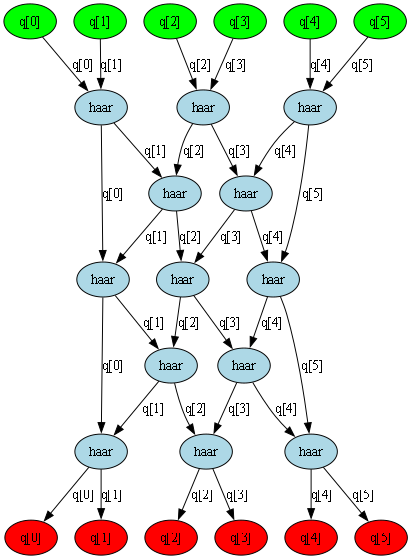

Saved figure to: C:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\qqe\notebooks\final\graph_haar_6q_5l.png


In [88]:
from IPython.display import display, Image as IPyImage
from PIL import Image as PILImage
from io import BytesIO

outdir = Path("final")
outdir.mkdir(parents=True, exist_ok=True)

outfile = outdir / f"graph_{family}_{n_qubits}q_{n_layers}l.png"

try:
    # Case 1: PIL image
    if isinstance(img, PILImage.Image):
        img_to_save = img.convert("RGB") if img.mode == "RGBA" else img
        img_to_save.save(outfile, format="PNG", dpi=(300, 300))
        display(img_to_save)

    # Case 2: Matplotlib figure
    elif hasattr(img, "savefig"):
        img.savefig(outfile, dpi=300, bbox_inches="tight")
        display(img)

    # Case 3: fallback, redraw as matplotlib
    else:
        fig = qc.draw(output="mpl")
        fig.savefig(outfile, dpi=300, bbox_inches="tight")
        display(fig)

    print(f"Saved figure to: {outfile.resolve()}")

except Exception as e:
    print(f"Could not save figure: {e}")

    try:
        bio = BytesIO()
        img.save(bio, format="PNG")
        display(IPyImage(data=bio.getvalue(), format="png"))
    except Exception:
        fig = qc.draw(output="mpl")
        display(fig)

In [89]:
fig = qc.draw(output="mpl", vertical_compression="low", fold=-1)
fig.savefig(f"final/circuit_{family}_{n_qubits}q_{n_layers}l.png", dpi=300, bbox_inches="tight")

# Résultats pour le calcul théorique brute sur 1 seul régime (identity-like et saturé)

### Calcul du SRE pour n=12 qubits